Exploratory Data Analysis

import all libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 


Load dataset

In [3]:
df = pd.read_csv("F:\\Project\\Covid_Project\\data_analysis\\data\\covid_19_clean_complete.csv")

Analize thee dataset

In [4]:
df.head(10)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa
5,NaN,Antigua and Barbuda,17.06080,-61.796400,2020-01-22,0,0,0,0,Americas
6,NaN,Argentina,-38.41610,-63.616700,2020-01-22,0,0,0,0,Americas
7,NaN,Armenia,40.06910,45.038200,2020-01-22,0,0,0,0,Europe
8,Australian Capital Territory,Australia,-35.47350,149.012400,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia,-33.86880,151.209300,2020-01-22,0,0,0,0,Western Pacific




check shape of dataset

In [5]:
df.shape

(49068, 10)

Check info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


Date column is in object format, so it needs to change be converted into datetime for proper date analysis

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

check the value_count every column

In [8]:
for i in df.columns:
    print(df[i].value_counts())

Province/State
Australian Capital Territory    188
Yunnan                          188
Mayotte                         188
Guadeloupe                      188
French Polynesia                188
                               ... 
Guizhou                         188
Guangxi                         188
Guangdong                       188
Gansu                           188
Saint Pierre and Miquelon       188
Name: count, Length: 78, dtype: int64
Country/Region
China             6204
Canada            2256
France            2068
United Kingdom    2068
Australia         1504
                  ... 
Holy See           188
Honduras           188
Hungary            188
Iceland            188
Lesotho            188
Name: count, Length: 187, dtype: int64
Lat
 52.939900    376
 33.939110    188
 12.169600    188
 52.132600    188
-40.900600    188
             ... 
 11.825100    188
 18.735700    188
-1.831200     188
 26.820553    188
-29.610000    188
Name: count, Length: 260, dtype: int64
Lon

Check null values of each column

In [9]:
df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

check the percentage of null values

In [10]:
(df.isnull().sum()/df.shape[0])*100

Province/State    70.114943
Country/Region     0.000000
Lat                0.000000
Long               0.000000
Date               0.000000
Confirmed          0.000000
Deaths             0.000000
Recovered          0.000000
Active             0.000000
WHO Region         0.000000
dtype: float64

fill the null values of Province/State  column with the help of country column.

In [11]:

df['Province/State']=df['Province/State'].fillna(df['Country/Region'])

* The missing values in Province/State were replaced with the value of Country/Region to handle missing data.

Check duplicates of dataset

In [12]:
df.duplicated().sum()

np.int64(0)

* In this dataset there are no duplicate rows.

Show Statistics summary.

In [13]:
df.describe()

,Lat,Long,Date,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,49068,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,2020-04-24 12:00:00,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
min,-51.796300,-135.000000,2020-01-22 00:00:00,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,2020-03-08 18:00:00,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,2020-04-24 12:00:00,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,2020-06-10 06:00:00,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,2020-07-27 00:00:00,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06
std,24.950320,70.442740,NaN,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04


The dataset contain 49068 records. Confirmed case  show a large variation, with a maximum of apporximately 4.29 million cases.Deaths, recovered and active cases also very significant across locations.The negative minimum value of active cases(-14)indicates a possible data anomaly.

Chcek outliers

In [14]:
for i in df.columns:
   if df[i].dtype !='object':
      q1=df[i].quantile(0.25)
      q3=df[i].quantile(0.75)

      iqr=q3-q1

      l=q1-1.5*iqr
      u=q3+1.5*iqr

      out=df[(df[i]<l)|(df[i]>u)]
      print(i,"-",len(out))

Lat - 376
Long - 0
Date - 0
Confirmed - 8817
Deaths - 9077
Recovered - 7936
Active - 8914


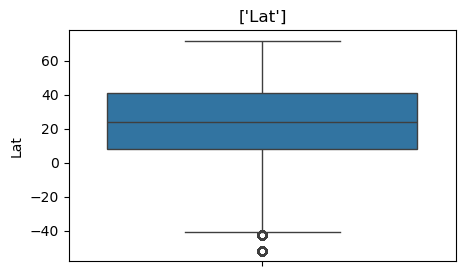

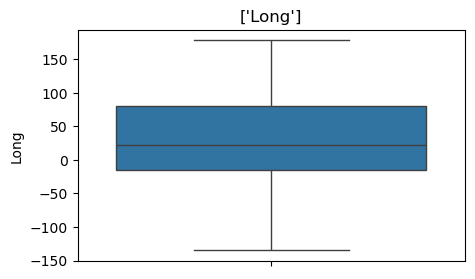

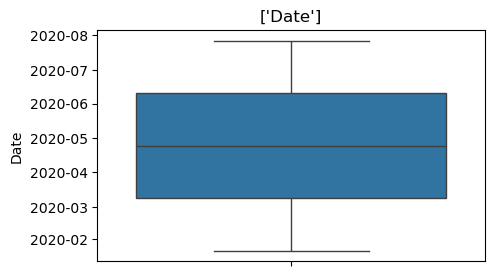

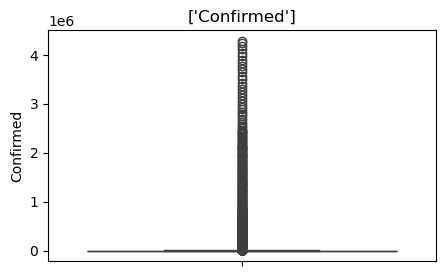

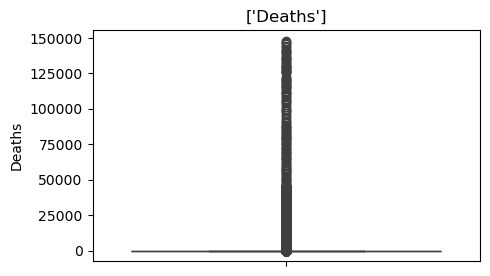

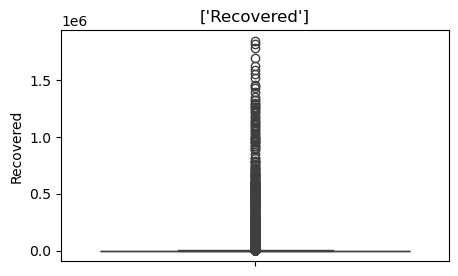

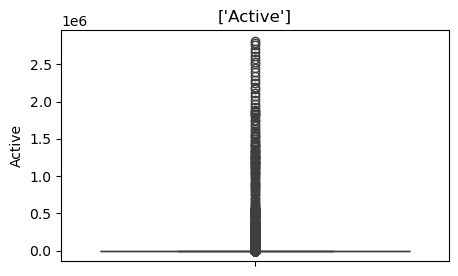

In [15]:
for i in df.columns:
    if df[i].dtype!="object":
        plt.figure(figsize=(5,3))
        sns.boxplot(data=df[i])
        plt.title([i])

Outliers were identified but they were retained because they represent genuine variation in COVID-19 cases rathan than data-entry errors.

* create copy of the original dataset.

In [16]:
df1=df.copy()

The copied dataset used for preprocessing and model training, while the original dataset kept unchanged.

* Apply one hot encoding to WHO Region.

In [17]:
from sklearn.preprocessing import LabelEncoder
df1=pd.get_dummies(df1, columns=['WHO Region'], drop_first=False,dtype=int)

* Remove non-predictive columns.

In [18]:
x=df1.drop(columns=['Country/Region','Province/State','Date'])

* Standardize the features using StandardScaler 

In [19]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_scaled=sc.fit_transform(x)

* Apply the elbow method to determine the optimal numberof clusters.

In [20]:
from sklearn.cluster import KMeans
K=[2,3,4,5,6,7,8]
ssd=[]
for i in K:
  KModel = KMeans(n_clusters=i,random_state=42,max_iter=100)
  KModel.fit(x_scaled)
  ssd.append(KModel.inertia_)

* Plot the Elbow method graph.

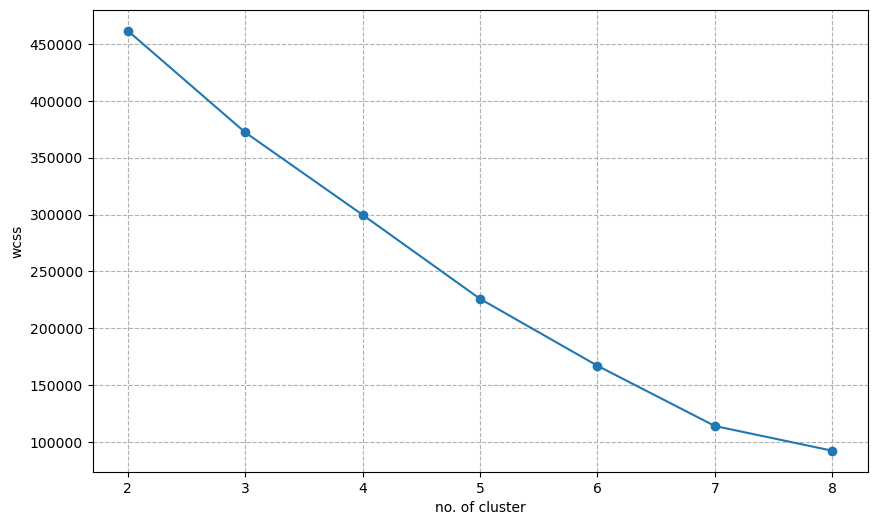

In [21]:
plt.figure(figsize=(10,6))
plt.plot(K,ssd,marker="o")
plt.xlabel("no. of cluster")
plt.ylabel("wcss")
plt.grid(True,ls="--")
plt.show()

* The elbow method suggests that 7 clusters are suitable for the dataset, as reduction in WCSS become smaller after   k= 7.

In [22]:
fmodel = KMeans(n_clusters=7, random_state=42,max_iter=100)
fmodel.fit(x_scaled)

,n_clusters,7
,init,'k-means++'
,n_init,'auto'
,max_iter,100
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


* Assign cluster labels to each data point.

In [23]:
df1['ClusterId']=fmodel.labels_

* Display cluster counts.

In [24]:
df1['ClusterId'].value_counts()

ClusterId
0    15040
2    10340
3     9024
4     8518
5     4136
6     1873
1      137
Name: count, dtype: int64

In [25]:
import pickle
with open('Kmeans_model.pkl','wb') as file:
    pickle.dump(fmodel,file)


In [26]:
with open('scaler.pkl','wb') as file:
    pickle.dump(sc,file)

In [27]:
with open('features_names.pkl','wb')as file:
    pickle.dump(x.columns.tolist(),file)